Importar librerías y dataset

In [3]:
import pandas as pd

#Import the dataset
dataset = 'CTC_processed.csv'
                              
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

data.head(10)

,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure,month,day,hour,minute
0,65,17.6,24.1,100.0,55.0,0.0,29.9,1,24,13,10
1,70,17.6,22.5,105.0,54.0,0.0,29.9,1,24,13,15
2,82,17.7,17.7,114.0,53.0,0.0,29.9,1,24,13,25
3,78,17.7,27.4,105.0,53.0,0.0,29.9,1,24,13,30
4,69,17.9,27.4,97.0,52.0,0.0,29.9,1,24,13,35
5,61,17.9,29.0,93.0,51.0,0.0,29.9,1,24,13,40
6,70,18.1,14.5,105.0,51.0,0.0,29.9,1,24,13,50
7,71,18.1,29.0,105.0,51.0,0.0,29.9,1,24,13,55
8,68,18.1,22.5,104.0,51.0,0.0,29.9,1,24,14,0
9,60,18.1,17.7,97.0,52.0,0.0,29.9,1,24,14,10


Separamos las variables predictoras y objetivo.

In [4]:
#Eliminamos filas con valores NaN antes de dividir en train y test
df_clean = data.dropna(subset=['Power_gen'])
predictors = df_clean.drop(columns=['Power_gen'])
objective = df_clean['Power_gen']

Dividimos los datos en train y test

In [5]:
#Dividimos los datos en train y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(predictors, objective, test_size=0.2, random_state=42) #20% para test

Calculamos los parámetros óptimos del modelo.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {'max_depth': [2, 5, 9], #profundidad maxima del arbol
          'n_estimators': [50, 100, 900], #numero de arboles
          'max_features': [1, 'sqrt', None]}
pruebas = RandomForestRegressor()
grid = GridSearchCV(pruebas, params, scoring='neg_root_mean_squared_error', cv=2, verbose=2) #calculamos el valor optimo de los parametros
grid.fit(X_train, y_train)
print(grid.best_params_)


Fitting 2 folds for each of 27 candidates, totalling 54 fits
[CV] END ........criterion=gini, max_depth=2, max_features=1; total time=   0.0s
[CV] END ........criterion=gini, max_depth=2, max_features=1; total time=   0.0s
[CV] END .....criterion=gini, max_depth=2, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=2, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=2, max_features=None; total time=   0.0s
[CV] END .....criterion=gini, max_depth=2, max_features=None; total time=   0.0s
[CV] END ........criterion=gini, max_depth=5, max_features=1; total time=   0.0s
[CV] END ........criterion=gini, max_depth=5, max_features=1; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_features=None; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_f

c:\Users\guill\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
36 fits failed out of a total of 54.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\guill\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\guill\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\guill\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    

{'criterion': 'poisson', 'max_depth': 9, 'max_features': None}


Creamos el modelos y controlamos el sobreajuste.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(max_depth = 9, max_features = None,n_estimators = 900) #aplicamos los parametros optimos obtenidos
rfr.fit(X_train, y_train)  #entrenamos el modelo

RandomForestRegressor(criterion='poisson', max_depth=9, max_features=None,
                      n_estimators=900)

Predicción y análisis

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = rfr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
r2_ajustado = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print("MAE: ", mae) #MAE = Error medio en la prediccion
print("MSE:", mse) #MSE = Error cuadratico medio en la prediccion
print("RMSE:", rmse) #RMSE = Raiz del error cuadratico medio en la prediccion
print("R²:", r2) #R^2 = Coeficiente de determinacion
print("R2 ajustado:", r2_ajustado) #R^2 ajustado, si es parecido al normal indica que no hay overfitting ni variables irrelevantes

MAE:  35.18345994190158
MSE: 4973.485109903609
RMSE: 70.52294030954472
R²: 0.9198086195552486
R2 ajustado: 0.9196469433849971


Obtener varaibles más importantes en la predicción

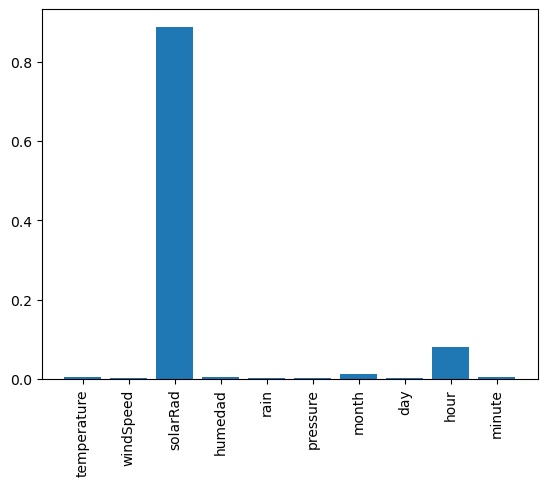

In [9]:
import matplotlib.pyplot as plt
plt.bar(X_train.columns, rfr.feature_importances_)
plt.xticks(rotation=90)
plt.show()


Comparativa predicción vs realidad

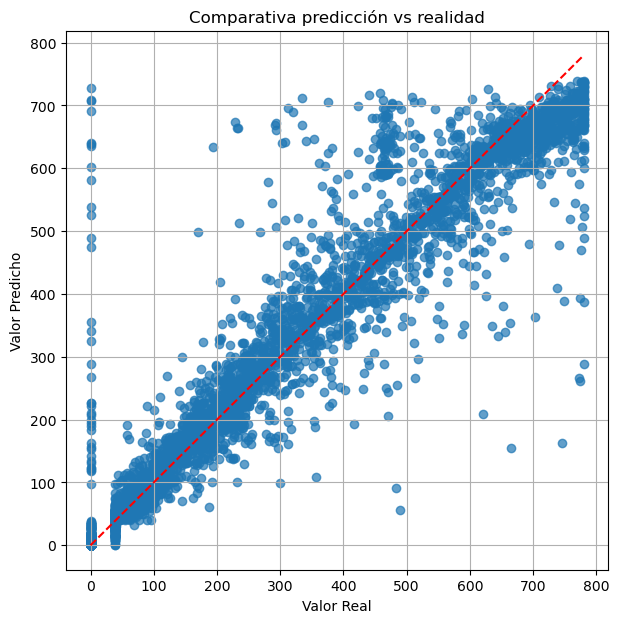

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()
